Phase 1 — Experiment 4 ORDER ONLY

pred_len: 96 and 192 only All 3 alphas: 0.5, 1.0, 2.0 1 seed only (say 2021)

That's 2 × 3 × 1 = 6 runs

In [1]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
import os

project_path = '/content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1'
os.chdir(project_path)

print("Current Directory:", os.getcwd())

Current Directory: /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1


In [3]:
!ls -la experiments/exp4_order_only/exp4_order_only.sh

-rw------- 1 root root 7704 Apr  5 13:39 experiments/exp4_order_only/exp4_order_only.sh


In [4]:
import os

# Set your Informer data directory
informer_path = f'{project_path}/Informer2020-original'
data_dir = f'{informer_path}/data/ETT'
os.makedirs(data_dir, exist_ok=True)

# File path
data_file = f'{data_dir}/ETTh1.csv'

# Download ETTh1 dataset
if not os.path.exists(data_file):
    print("Downloading ETTh1.csv...")
    os.system(
        f'wget -q "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv" '
        f'-O "{data_file}"'
    )

# Verify
if os.path.exists(data_file):
    print(f"✅ Download successful: {data_file}")
else:
    print("❌ Download failed.")

✅ Download successful: /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1/Informer2020-original/data/ETT/ETTh1.csv


In [5]:
# Fix np.Inf -> np.inf in tools.py (removed in NumPy 2.0)
tools_path = f'{project_path}/Informer2020-original/utils/tools.py'

with open(tools_path, 'r') as f:
    content = f.read()

content_fixed = content.replace('np.Inf', 'np.inf')

with open(tools_path, 'w') as f:
    f.write(content_fixed)

print("✅ Fixed np.Inf -> np.inf in utils/tools.py")

✅ Fixed np.Inf -> np.inf in utils/tools.py


In [6]:
!bash experiments/exp4_order_only/exp4_order_only.sh

Experiment 4 — Phase 1: Ordering Only
Formula   : X'_i = X_i + T_i + O_i
Value     : TokenEmbedding (semantic content)
Temporal  : TimeFeatureEmbedding
Order     : O_i = (1/N-1) * sum_j(X_i - X_j)
  Signed displacements — pure directional signal
  NO index-based decay alpha(i,j)
  NO feature-space weighting w_ij
  NO Legendre labels

Seed      : 2021 | Pred lengths: 96, 192 | Total runs: 2
Start: Sun Apr  5 01:42:33 PM UTC 2026

Copying experiment files...
Files copied successfully.

------------------------------------------------------------
RUN 1/2: exp4_ph1_ETTh1_ordering_pred96_seed2021
pred_len=96 | seed=2021 | config=ordering_only
Start: Sun Apr  5 01:42:41 PM UTC 2026
Args in experiment:
Namespace(model='informer', data='ETTh1', root_path='./data/ETT/', data_path='ETTh1.csv', features='M', target='OT', freq='h', checkpoints='./checkpoints/', seq_len=96, label_len=48, pred_len=96, enc_in=7, dec_in=7, c_out=7, d_model=512, n_heads=8, e_layers=2, d_layers=1, s_layers=[3, 2, 1], d_

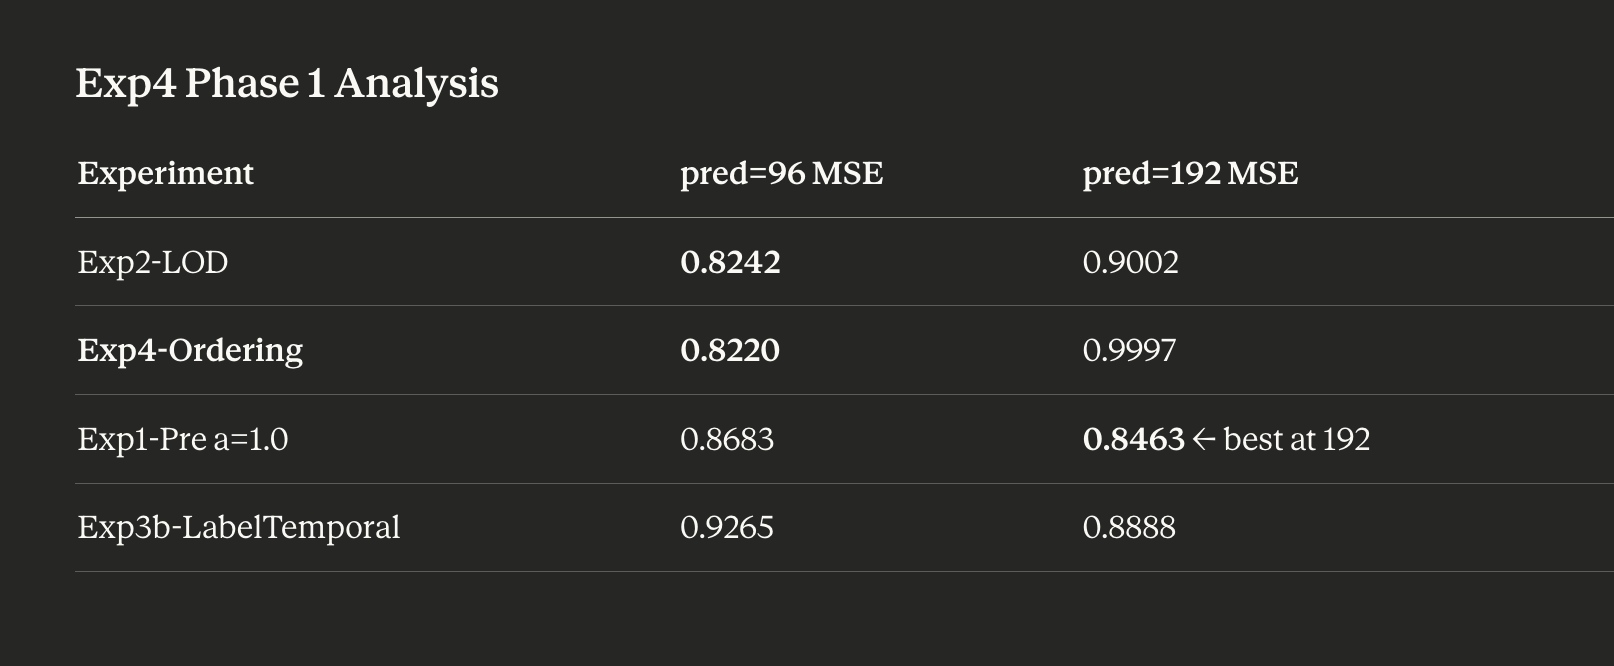

## What You Should Notice

- **Mixed pattern — same as Exp3b but worse at 192**
  
- At `pred_len = 96`, **Exp4 gives the best single result seen so far (0.822)**, even beating **Exp2-LOD (0.824)**.  
  - The pure ordering signal — *signed displacements without any decay or Legendre* — is genuinely useful at short horizons.

- At `pred_len = 192`, however, **it collapses to 0.9997**  
  - This is worse than every previous experiment except **Exp3 (label only, no temporal)**  
  - This represents a significant performance drop.

---

## Additional Concern: Epoch Time

- `pred_len = 96` → ~57–61 seconds per epoch  
- `pred_len = 192` → ~110 seconds per epoch  

- The ordering operator computes **pairwise O(L²) displacements**, the same issue seen in **Exp2-LOD**  
- At `pred_len = 336` and `720`, this will likely become **very slow**

---

## Decision

- **Proceed to Phase 2**
  - The `pred_len = 96` win is strong enough to validate

- Next steps:
  - Check if results hold across multiple seeds  
  - Verify whether the `pred_len = 192` collapse is consistent or just due to `seed = 2021`

***REMOVED PRED LENGTH 336 AND 742 KEEPING TIME AND COMPUTE ON MIND***

In [11]:
!bash experiments/exp4_order_only/exp4_order_ony_phase2.sh

Experiment 4 — Phase 2: Ordering Only
Formula   : X'_i = X_i + T_i + O_i
O_i       : (1/N-1) * sum_j(X_i - X_j)
  Uniform signed displacements — no decay, no Legendre

Phase 1 note: pred=96  MSE=0.8220 ← best seen so far
              pred=192 MSE=0.9997 ← worse than Exp1-Pre
              Epoch time ~60s at pred=96, ~110s at pred=192

Seeds     : 2021, 2022, 2023
Pred lens : 48, 96, 192 (720 skipped — O(L²) too slow)
Total runs: 9 (1 config × 3 seeds × 3 pred_lens)
Start: Sun Apr  5 02:09:40 PM UTC 2026

Copying experiment files...
Files copied successfully.

------------------------------------------------------------
RUN 1/9: exp4_ph2_ETTh1_ordering_pred48_seed2021
pred_len=48 | seed=2021 | config=ordering_only
Start: Sun Apr  5 02:09:40 PM UTC 2026
Args in experiment:
Namespace(model='informer', data='ETTh1', root_path='./data/ETT/', data_path='ETTh1.csv', features='M', target='OT', freq='h', checkpoints='./checkpoints/', seq_len=96, label_len=48, pred_len=48, enc_in=7, dec_in=7, c

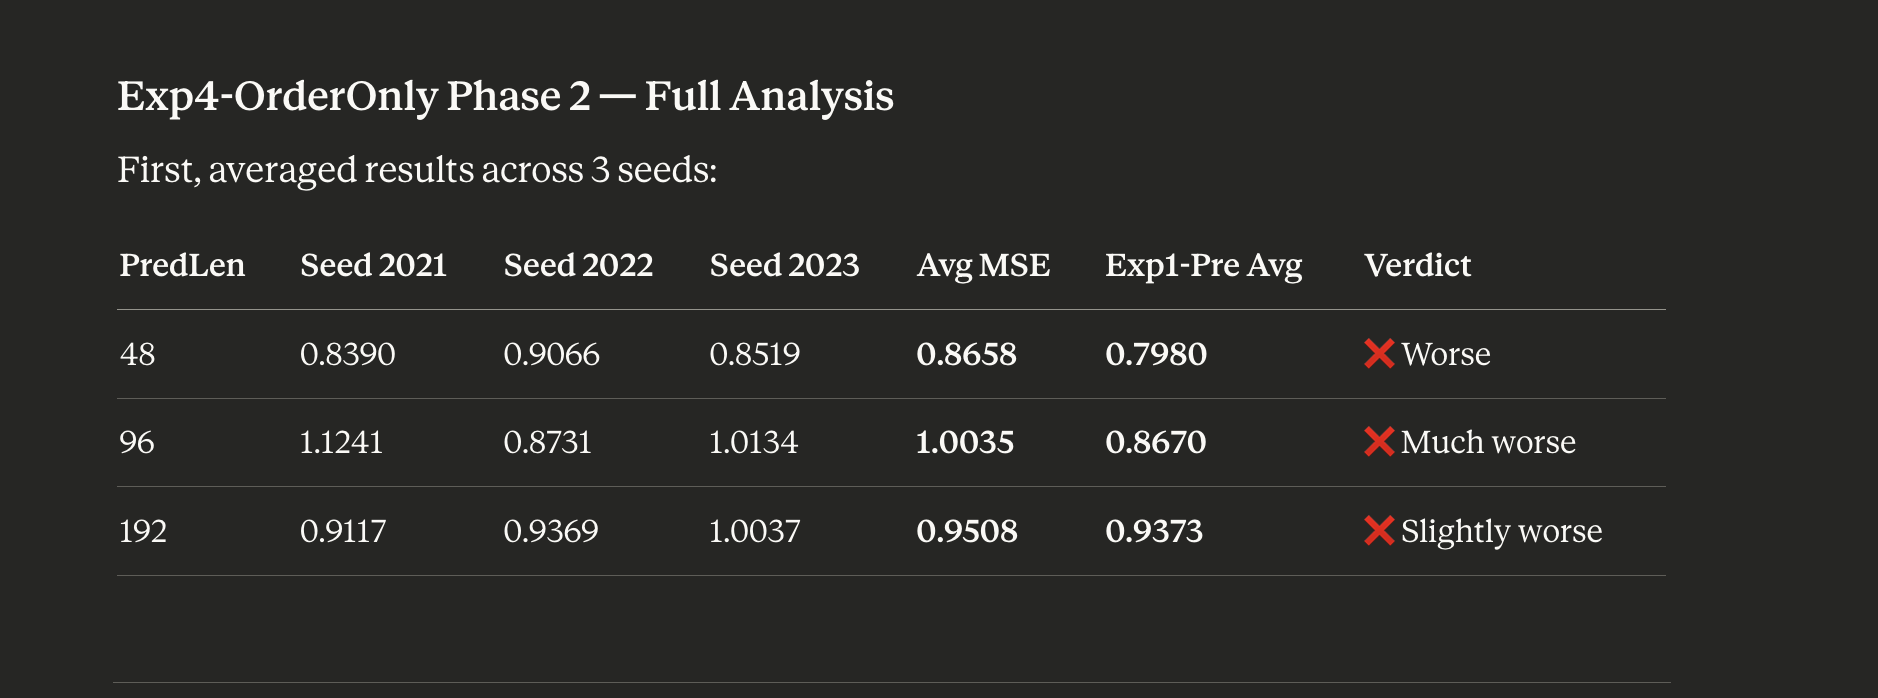

## What You Should Note

The Phase 1 win at pred=96 (0.822) was a lucky seed. Across 3 seeds the average MSE at pred=96 is 1.003 — significantly worse than Exp1-Pre (0.867). Seed 2021 got 0.822, but seed 2022 got 0.873 and seed 2023 got 1.013. This is a massive spread of 0.25 — the most unstable result we've seen at pred=96 across any experiment.

Exp4-OrderOnly is consistently worse than Exp1-Pre at all horizons. No pred_len shows a reliable improvement.

The O(L²) pairwise computation is both slow AND unstable. Epoch times of 110 seconds at pred=192 for a result that's worse than everything — this is not worth the compute cost.

Comparison with Exp4b is revealing. Exp4b (consecutive Legendre deltas in attention values) gets avg MSE ~0.854 stably at both pred=96 and pred=192. Exp4-OrderOnly gets 1.003 at pred=96 with high variance. The mean-field global displacement (Σ all pairs) is fundamentally less stable than consecutive local deltas.


## Exp4-OrderOnly Conclusion to Document

The global mean-field ordering operator O_i = (1/N-1)·Σ_{j≠i}(X_i - X_j) applied in the embedding space shows highly unstable results across seeds at pred_len=96 (MSE range: 0.822–1.124, avg 1.003) and is consistently worse than Exp1-Pre across all prediction horizons. The Phase 1 single-seed result of 0.822 was misleading — it did not hold across seeds. The O(L²) pairwise computation adds significant compute overhead (~60-110s per epoch) with no performance benefit. Exp4-OrderOnly is a negative result — the global mean-field ordering operator in embedding space does not provide reliable positional signal for time series forecasting.


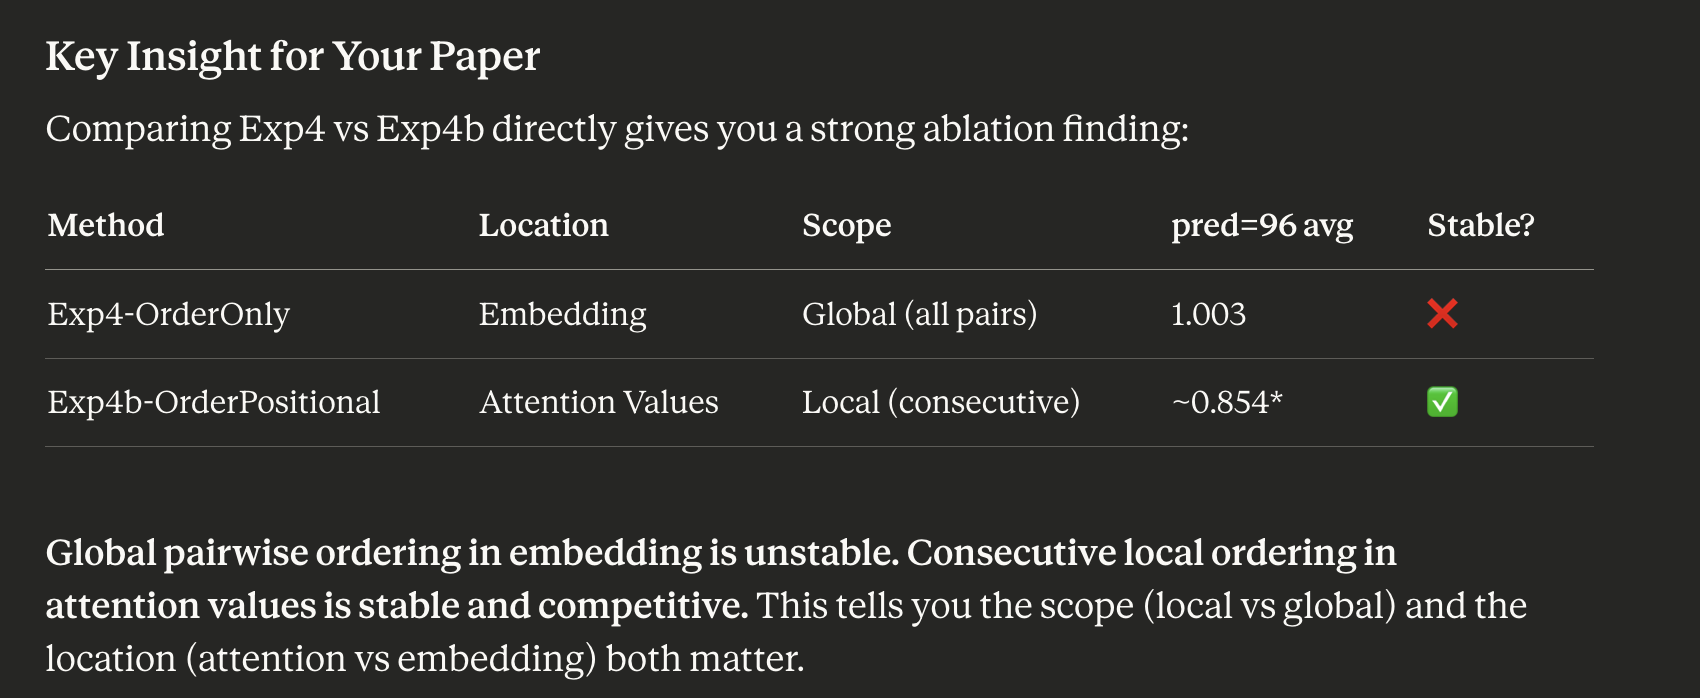